In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pickle as p

In [16]:
def plot_metrics_over_time():
    with open("../results/fb15k_10_0.001_cosine_0.1_test_positive/metrics_over_time.pkl", "rb") as f:
        total_metrics_over_t_10 = p.load(f)
    # Plot metrics over time for queries with 10 answers
    # Extract data for MRR_hard and pairwise_accuracy
    mrr_hard = total_metrics_over_t_10['mrr_hard']  # List of lists
    hits_at_10 = total_metrics_over_t_10['hits@10_hard']  # List of lists
    pairwise_acc = total_metrics_over_t_10['pairwise_accuracy']  # List of lists

    # Convert lists of lists into numpy arrays for easier manipulation
    mrr_hard = np.array(mrr_hard)  # Shape: (num_queries, num_timesteps)
    hits_at_10 = np.array(hits_at_10)  # Shape: (num_queries, num_timesteps)
    pairwise_acc = np.array(pairwise_acc)  # Shape: (num_queries, num_timesteps)

    # Define time steps
    num_timesteps = mrr_hard.shape[1]
    time_steps = np.arange(1, num_timesteps + 1)
    # Create subplots for boxplots
    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    # Metrics and titles for looping
    metrics = [pairwise_acc, mrr_hard, hits_at_10]
    titles = ['Pairwise Accuracy', '$\Delta$MRR', '$\Delta$Hits@10']

    # Loop over the metrics and plot boxplots
    for ax, metric, title in zip(axes, metrics, titles):
        ax.boxplot(metric, positions=time_steps, widths=0.6, medianprops={'color': 'black'}, showfliers=False)
        ax.grid(True, linestyle='--', alpha=0.7)
        ax.set_title(title)
        ax.set_xlabel('Number of interactions')
        ax.set_ylabel('Value')
        if title == 'Pairwise Accuracy':
            ax.set_ylim(-0.1, 1.1)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        ax.axhline(0, color='black', linewidth=1)  # Horizontal line at y=0
        ax.axvline(0, color='black', linewidth=1)  # Vertical line at x=0

    fig.suptitle('Distribution of Metrics Over Time')
    plt.tight_layout()
    plt.show()

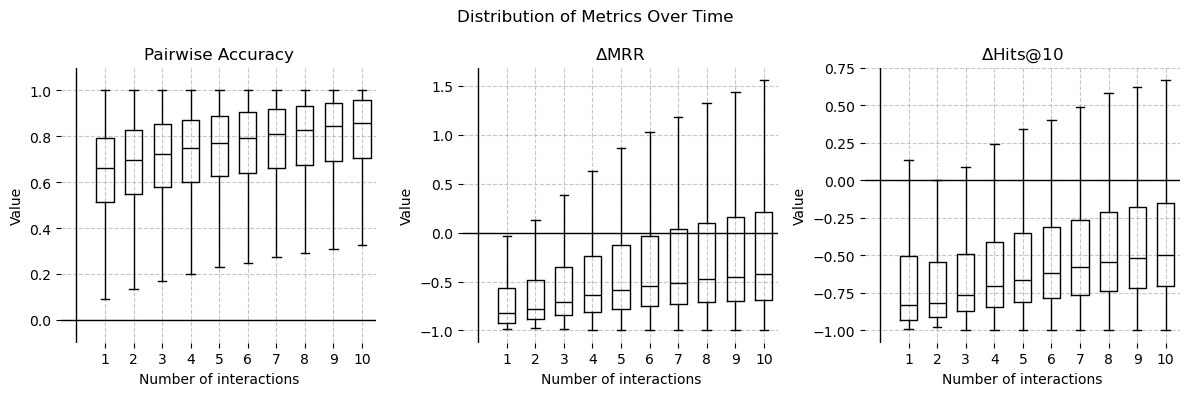

In [17]:
# test, pos preference
plot_metrics_over_time()